In [ ]:
!pip install opencv-python

In [ ]:
import os
import shutil
import scipy.io as sio
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import torchvision.models as models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import cv2
import torch.nn.functional as F

import xml.etree.ElementTree as ET
from PIL import Image, ImageFile

ImageFile.LOAD_TRUNCATED_IMAGES = True

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


# 데이터 준비

- stanford_dogs 데이터셋은 12,000장의 학습용 데이터셋과 8,580장의 평가용 데이터셋으로 구성되어있습니다.

In [ ]:
!wget http://vision.stanford.edu/aditya86/ImageNetDogs/images.tar
!wget http://vision.stanford.edu/aditya86/ImageNetDogs/annotation.tar
!wget http://vision.stanford.edu/aditya86/ImageNetDogs/lists.tar
!tar -xf images.tar -C ~/work/class_activation_map/
!tar -xf annotation.tar -C ~/work/class_activation_map/
!tar -xf lists.tar -C ~/work/class_activation_map/

print("데이터 다운로드 완료!")

--2026-08-27 08:53:16--  http://vision.stanford.edu/aditya86/ImageNetDogs/images.tar
Resolving vision.stanford.edu (vision.stanford.edu)... 171.64.68.10
Connecting to vision.stanford.edu (vision.stanford.edu)|171.64.68.10|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 793579520 (757M) [application/x-tar]
Saving to: ‘images.tar’

images.tar          100%[===================>] 756.82M  9.28MB/s    in 57s     

2026-08-27 08:54:13 (13.3 MB/s) - ‘images.tar’ saved [793579520/793579520]

--2026-08-27 08:54:13--  http://vision.stanford.edu/aditya86/ImageNetDogs/annotation.tar
Resolving vision.stanford.edu (vision.stanford.edu)... 171.64.68.10
Connecting to vision.stanford.edu (vision.stanford.edu)|171.64.68.10|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 21852160 (21M) [application/x-tar]
Saving to: ‘annotation.tar’

annotation.tar      100%[===================>]  20.84M  17.0MB/s    in 1.2s    

2026-08-27 08:54:15 (17.0 MB/s) - ‘annotat

Stanford Dogs 데이터셋은 다음과 같이 구성되어있습니다.

- Images 폴더

각 폴더 내에는 class 별 폴더로 구성되어있고 내부에는 이미지가 저장되어있습니다.
- Annotation 폴더

Images와 마찬가지로 class 별 폴더로 구성되어있고 내부에는 각 이미지에 대한 메타데이터가 저장되어있습니다.
- list.mat 파일

각 파일 내에는 train/test 셋의 파일명이 정리되어있습니다.

In [ ]:
import os
import tarfile

# lists.tar 압축 해제
with tarfile.open('/content/lists.tar', 'r') as tar:
    tar.extractall('/content')

# images.tar 압축 해제
with tarfile.open('/content/images.tar', 'r') as tar:
    tar.extractall('/content')

# annotation.tar 압축 해제
with tarfile.open('/content/annotation.tar', 'r') as tar:
    tar.extractall('/content')

print(os.listdir('/content'))

/tmp/ipykernel_607/1017910382.py:6: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall('/content')
/tmp/ipykernel_607/1017910382.py:10: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall('/content')
/tmp/ipykernel_607/1017910382.py:14: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall('/content')


['.config', 'Images', 'lists.tar', 'file_list.mat', 'images.tar', 'annotation.tar', 'test_list.mat', 'train_list.mat', 'Annotation', 'sample_data']


In [ ]:
import os

print("=== /content ===")
print(os.listdir('/content'))

print("\n=== .mat 파일 ===")
for root, dirs, files in os.walk('/content'):
    for file in files:
        if file.endswith('.mat'):
            print(os.path.join(root, file))

print("\n=== Images 확인 ===")
print(os.path.exists('/content/Images'))

=== /content ===
['.config', 'Images', 'lists.tar', 'file_list.mat', 'images.tar', 'annotation.tar', 'test_list.mat', 'train_list.mat', 'Annotation', 'sample_data']

=== .mat 파일 ===
/content/file_list.mat
/content/test_list.mat
/content/train_list.mat

=== Images 확인 ===
True


In [ ]:
import os
import shutil
import scipy.io as sio


# 원본 데이터 경로
mat_dir = '/content'
images_dir = '/content/Images'

train_mat_path = os.path.join(mat_dir, 'train_list.mat')
test_mat_path = os.path.join(mat_dir, 'test_list.mat')


# 파일 존재 여부 확인
print("train_list.mat:", os.path.exists(train_mat_path))
print("test_list.mat :", os.path.exists(test_mat_path))
print("Images        :", os.path.exists(images_dir))


# .mat 파일 로드
train_mat = sio.loadmat(train_mat_path)
test_mat = sio.loadmat(test_mat_path)

train_file_list = train_mat['file_list']
train_labels = train_mat['labels'].squeeze()

test_file_list = test_mat['file_list']
test_labels = test_mat['labels'].squeeze()

print("\nTrain 이미지 수:", len(train_file_list))
print("Test 이미지 수 :", len(test_file_list))


# ImageFolder 구조 생성
base_dir = '/content/stanford_dogs'

train_dir = os.path.join(base_dir, 'train')
test_dir = os.path.join(base_dir, 'test')

os.makedirs(train_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)


# 이미지 복사 함수
def process_mat_file(file_list_array, split_dir):

    num_files = file_list_array.shape[0]

    print(f"\n총 {num_files}개 이미지 처리 시작")

    copied = 0
    missing = 0

    for idx in range(num_files):

        # file_list에서 파일 경로 추출
        file_path = file_list_array[idx][0]

        # numpy array / scalar 처리
        while hasattr(file_path, 'shape') and file_path.shape != ():
            file_path = file_path.item()

        if isinstance(file_path, bytes):
            file_path = file_path.decode('utf-8')

        file_path = str(file_path)

        # Windows / Linux 경로 차이 방지
        file_path = file_path.replace('\\', '/')

        # 클래스 이름 추출
        #
        # n02116738-African_hunting_dog/n02116738_2988.jpg → n02116738-African_hunting_dog
        class_folder = file_path.split('/')[0]


        # 목적지 클래스 폴더 생성
        dest_folder = os.path.join(
            split_dir,
            class_folder
        )

        os.makedirs(
            dest_folder,
            exist_ok=True
        )


        # 원본 이미지 경로
        src_path = os.path.join(
            images_dir,
            file_path
        )


        # 복사할 이미지 경로
        dest_path = os.path.join(
            dest_folder,
            os.path.basename(file_path)
        )


        # 이미지 복사
        if os.path.exists(src_path):

            shutil.copy2(
                src_path,
                dest_path
            )

            copied += 1

        else:

            print(f"File not found: {src_path}")
            missing += 1


        # 진행 상황 출력
        if (idx + 1) % 1000 == 0:
            print(
                f"{idx + 1}/{num_files} "
                f"처리 완료"
            )


    print(
        f"완료: copied={copied}, missing={missing}"
    )


# Train 데이터 처리
print("\n==============================")
print("Processing train set...")
print("==============================")

process_mat_file(
    train_file_list,
    train_dir
)


# Test 데이터 처리
print("\n==============================")
print("Processing test set...")
print("==============================")

process_mat_file(
    test_file_list,
    test_dir
)


print("\n================================")
print("Dataset reorganization complete!")
print("================================")

print("\nTrain directory:")
print(train_dir)

print("\nTest directory:")
print(test_dir)

train_list.mat: True
test_list.mat : True
Images        : True

Train 이미지 수: 12000
Test 이미지 수 : 8580

Processing train set...

총 12000개 이미지 처리 시작
1000/12000 처리 완료
2000/12000 처리 완료
3000/12000 처리 완료
4000/12000 처리 완료
5000/12000 처리 완료
6000/12000 처리 완료
7000/12000 처리 완료
8000/12000 처리 완료
9000/12000 처리 완료
10000/12000 처리 완료
11000/12000 처리 완료
12000/12000 처리 완료
완료: copied=12000, missing=0

Processing test set...

총 8580개 이미지 처리 시작
1000/8580 처리 완료
2000/8580 처리 완료
3000/8580 처리 완료
4000/8580 처리 완료
5000/8580 처리 완료
6000/8580 처리 완료
7000/8580 처리 완료
8000/8580 처리 완료
완료: copied=8580, missing=0

Dataset reorganization complete!

Train directory:
/content/stanford_dogs/train

Test directory:
/content/stanford_dogs/test


image, label(클래스 번호)만 반환하는 `ImageFolder`를 확장해서 바운딩 박스까지 반환하도록 확장

In [ ]:
class StanfordDogsDatasetWithBBox(datasets.ImageFolder):
    def __init__(self, root, annotation_root, transform=None):
        super().__init__(root, transform=transform)
        self.annotation_root = annotation_root  # 예: '/content/Annotation'
        self.new_size = (224, 224)

    def __getitem__(self, index):
        image, label = super().__getitem__(index)
        path, _ = self.samples[index]

        rel_path = os.path.relpath(path, self.root)
        annot_filename = os.path.splitext(os.path.basename(rel_path))[0]
        annot_folder = os.path.dirname(rel_path)
        annot_path = os.path.join(self.annotation_root, annot_folder, annot_filename)

        # bbox 기본값 (예: [ymin, xmin, ymax, xmax])
        bbox = [0.0, 0.0, 0.0, 0.0]

        if os.path.exists(annot_path):
            try:
                # 확장자가 없지만 XML 형식의 파일이라고 가정하고 파싱
                tree = ET.parse(annot_path)
                root_xml = tree.getroot()
                # 첫 번째 object 태그에서 bndbox 정보를 읽음
                obj = root_xml.find('object')
                if obj is not None:
                    bndbox = obj.find('bndbox')
                    if bndbox is not None:
                        xmin = float(bndbox.find('xmin').text)
                        ymin = float(bndbox.find('ymin').text)
                        xmax = float(bndbox.find('xmax').text)
                        ymax = float(bndbox.find('ymax').text)
                        # XML 내 <size> 태그에서 원본 이미지 크기 획득
                        size = root_xml.find('size')
                        w = float(size.find('width').text)
                        h = float(size.find('height').text)
                        new_h, new_w = self.new_size
                        # bbox 좌표 순서: [ymin, xmin, ymax, xmax]
                        bbox = [xmin * (new_w / w), ymin * (new_h / h),
                                xmax * (new_w / w), ymax * (new_h / h)]
                    else:
                        print(f"bndbox 태그를 찾을 수 없습니다: {annot_path}")
                else:
                    print(f"object 태그를 찾을 수 없습니다: {annot_path}")
            except Exception as e:
                print(f"Error parsing {annot_path}: {e}")
        else:
            print(f"Annotation file not found: {annot_path}")

        return image, label, bbox



```
/content/stanford_dogs/train
             │
             ▼
 StanfordDogsDatasetWithBBox
             │
       ┌─────┼─────┐
       ▼     ▼     ▼
     image  label  bbox
       │     │     │
       └─────┼─────┘
             ▼
        DataLoader
             │
             ▼
        batch_size=12
             │
             ▼
       모델 학습 / 검증
```



In [ ]:
import os
from torch.utils.data import DataLoader
from torchvision import transforms


# 이미지 전처리
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])


# 데이터셋 경로
train_dir = '/content/stanford_dogs/train'
test_dir = '/content/stanford_dogs/test'

# Annotation 경로
annotation_dir = '/content/Annotation'


# Custom Dataset 생성
train_dataset = StanfordDogsDatasetWithBBox(
    root=train_dir,
    annotation_root=annotation_dir,
    transform=transform
)

valid_dataset = StanfordDogsDatasetWithBBox(
    root=test_dir,
    annotation_root=annotation_dir,
    transform=transform
)


# DataLoader 생성
batch_size = 12

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2
)


num_classes = len(train_dataset.classes)

print(f"Number of classes: {num_classes}")
print(f"Train samples: {len(train_dataset)}")
print(f"Test samples: {len(valid_dataset)}")

Number of classes: 120
Train samples: 12000
Test samples: 8580


Label index: 0
Class name: n02085620-Chihuahua
BBox [xmin, ymin, xmax, ymax]: [63.616, 32.32214765100671, 150.08, 187.91946308724832]


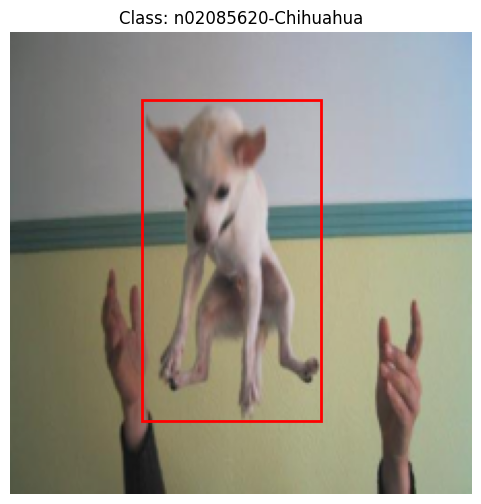

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np


def visualize(sample):

    img_tensor, label, bbox = sample

    # 클래스 정보
    class_name = train_dataset.classes[label]

    print("Label index:", label)
    print("Class name:", class_name)
    print("BBox [xmin, ymin, xmax, ymax]:", bbox)

    # Normalize 복원
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    img_np = img_tensor.permute(1, 2, 0).numpy()

    img_np = std * img_np + mean
    img_np = np.clip(img_np, 0, 1)

    # 이미지 출력
    fig, ax = plt.subplots(figsize=(6, 6))

    ax.imshow(img_np)

    # BBox 그리기
    xmin, ymin, xmax, ymax = bbox

    width = xmax - xmin
    height = ymax - ymin

    rect = patches.Rectangle(
        (xmin, ymin),
        width,
        height,
        linewidth=2,
        edgecolor='red',
        facecolor='none'
    )

    ax.add_patch(rect)

    ax.set_title(f"Class: {class_name}")
    ax.axis('off')

    plt.show()


# 첫 번째 샘플 확인
train_sample = train_dataset[0]
visualize(train_sample)

- **folder / filename**: Annotation과 연결된 이미지의 폴더와 파일 이름
- **source**: 이미지의 출처. 예시에서는 ImageNet
- **size**: 원본 이미지의 크기
- **segment**: Segmentation Mask 관련 정보. 0이면 별도의 Segmentation 정보가 없음
- **object**: 이미지에 포함된 객체 정보
- **name**: 객체의 클래스 이름 (Chihuahua)
- **pose**: 객체의 자세나 방향
- **truncated**: 객체가 이미지 경계에 의해 잘렸는지 여부 (0 = 잘리지 않음)
- **difficult**: 객체 인식 난이도 (0 = 비교적 쉬움)
- **bndbox**: 객체의 Bounding Box 좌표

In [ ]:
import os
import xml.etree.ElementTree as ET

annotation_path = '/content/Annotation/n02085620-Chihuahua/n02085620_10074'

# XML 파일 파싱
tree = ET.parse(annotation_path)
root = tree.getroot()

for elem in root.iter():
    print(f"{elem.tag}: {elem.text}")

annotation: 
	
folder: 02085620
filename: n02085620_10074
source: 
		
database: ImageNet database
size: 
		
width: 333
height: 500
depth: 3
segment: 0
object: 
		
name: Chihuahua
pose: Unspecified
truncated: 0
difficult: 0
bndbox: 
			
xmin: 25
ymin: 10
xmax: 276
ymax: 498


# 모델 준비
- ResNet50 사용
- CAM에 맞게 모델 수정

In [ ]:
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, len(train_dataset.classes))
model = model.to(device)

model

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 202MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

# Training

In [ ]:
def train_model(model, train_loader, valid_loader, criterion, optimizer, num_epochs=2):
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        print(f"\nEpoch {epoch+1}/{num_epochs} 시작")
        for batch_idx, (images, labels, _) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()
            if (batch_idx + 1) % 50 == 0:
                print(f"  Step {batch_idx+1} - Loss: {loss.item():.4f}")

        train_loss = running_loss / (batch_idx + 1)
        train_acc = correct / total
        print(f"Train - Loss: {train_loss:.4f}, Accuracy: {train_acc*100:.2f}%")

        # 검증 단계
        model.eval()
        running_loss = 0.0
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels, _ in valid_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                running_loss += loss.item()
                _, preds = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (preds == labels).sum().item()
        test_loss = running_loss / len(valid_loader)
        test_acc = correct / total
        print(f"Validation - Loss: {test_loss:.4f}, Accuracy: {test_acc*100:.2f}%")

In [ ]:
%%time

train_model(model, train_loader, valid_loader, criterion, optimizer, num_epochs=2)


Epoch 1/2 시작
  Step 50 - Loss: 3.5409
  Step 100 - Loss: 3.8679
  Step 150 - Loss: 3.9949
  Step 200 - Loss: 4.5526
  Step 250 - Loss: 2.9293
  Step 300 - Loss: 3.2700
  Step 350 - Loss: 2.9233
  Step 400 - Loss: 3.6074
  Step 450 - Loss: 3.6148
  Step 500 - Loss: 3.0164
  Step 550 - Loss: 3.5184
  Step 600 - Loss: 2.6147
  Step 650 - Loss: 3.2216
  Step 700 - Loss: 3.3071
  Step 750 - Loss: 2.3740
  Step 800 - Loss: 1.9447
  Step 850 - Loss: 2.5594
  Step 900 - Loss: 2.7927
  Step 950 - Loss: 2.0407
  Step 1000 - Loss: 1.9928
Train - Loss: 3.2177, Accuracy: 22.09%
Validation - Loss: 2.6966, Accuracy: 31.57%

Epoch 2/2 시작
  Step 50 - Loss: 2.0462
  Step 100 - Loss: 2.8158
  Step 150 - Loss: 2.4514
  Step 200 - Loss: 2.4632
  Step 250 - Loss: 2.9678
  Step 300 - Loss: 3.1873
  Step 350 - Loss: 2.5782
  Step 400 - Loss: 2.4567
  Step 450 - Loss: 2.3149
  Step 500 - Loss: 2.3377
  Step 550 - Loss: 3.5509
  Step 600 - Loss: 2.3624
  Step 650 - Loss: 2.6711
  Step 700 - Loss: 2.1689
  Step

In [ ]:
cam_model_path = '/content/cam_model.pt'

torch.save(model, cam_model_path)

# CAM

In [ ]:
def unnormalize(img_tensor):
    """
    img_tensor: [C, H, W] 텐서 (전처리 상태, 예: normalization 적용됨)
    ImageNet 평균 및 표준편차를 이용하여 복원 (RGB 순서)
    """
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    img = img_tensor.cpu().numpy().transpose(1, 2, 0)
    img = std * img + mean
    img = np.clip(img, 0, 1)
    img = np.uint8(255 * img)
    return img

In [ ]:
image, label, bbox = train_dataset[0]
sample_image = image.unsqueeze(0).to(device)

In [ ]:
model = torch.load(cam_model_path, weights_only=False)

In [ ]:
def generate_cam(model, image):
    model.eval()
    features = []

    def hook(module, input, output):
        features.append(output.detach())
    hook_handle = model.layer4.register_forward_hook(hook)

    output = model(image)
    hook_handle.remove()

    # 예측된 클래스 선택 (배치의 첫 번째 이미지 기준)
    pred_class = output.argmax(dim=1).item()

    # 모델의 fc layer 가중치가 모델과 동일한 디바이스에 있도록 처리
    fc_weights = model.fc.weight.data.to(image.device)

    # features[0]: shape [1, num_features, H, W]
    fmap = features[0][0]  # 첫 번째 이미지의 feature map
    cam = torch.zeros(fmap.shape[1:], dtype=torch.float32, device=image.device)

    # fc 가중치와 feature map의 각 채널을 가중합
    for i, w in enumerate(fc_weights[pred_class]):
        cam += w * fmap[i, :, :]
    cam = cam.cpu().numpy()

    # CAM 정규화
    cam = np.maximum(cam, 0)
    cam = (cam - np.min(cam)) / (np.max(cam) - np.min(cam) + 1e-8)

    return cam

In [ ]:
cam = generate_cam(model, sample_image)

In [ ]:
def visualize_cam(cam):
    plt.imshow(cam, cmap='jet')
    plt.colorbar()
    plt.title("CAM")
    plt.axis('off')
    plt.show()

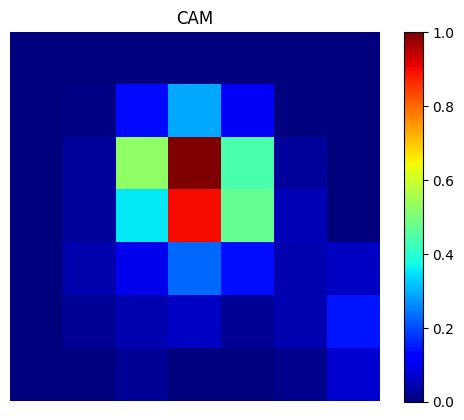

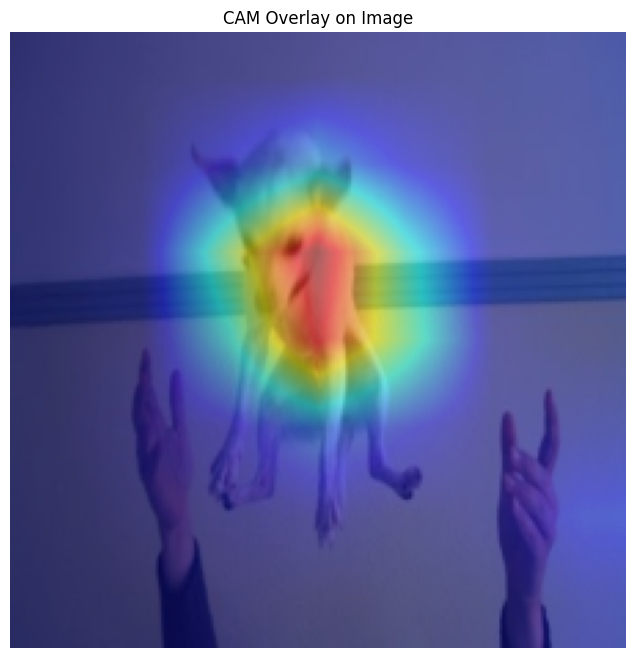

In [ ]:
def visualize_cam_on_image(cam, img, alpha=0.5):
    # CAM 크기를 원본 이미지 크기로 조정
    cam_resized = cv2.resize(cam, (img.shape[1], img.shape[0]))

    # CAM을 컬러 heatmap으로 변환 (cv2.applyColorMap는 BGR로 반환하므로 RGB로 변경)
    heatmap = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    # 원본 이미지와 heatmap을 alpha blending
    overlay = heatmap * alpha + img * (1 - alpha)
    overlay = overlay.astype(np.uint8)

    plt.figure(figsize=(8,8))
    plt.imshow(overlay)
    plt.title("CAM Overlay on Image")
    plt.axis('off')
    plt.show()


# 원본 이미지 복원
orig_img = unnormalize(image)

# CAM 단독 시각화
visualize_cam(cam)

# 원본 이미지 위에 CAM overlay 시각화
visualize_cam_on_image(cam, orig_img)

# Grad-CAM

In [ ]:
def generate_grad_cam(model, image, target_layer_name):
    model.eval()
    features = {}
    gradients = {}

    # forward hook: 대상 레이어의 출력을 저장
    def forward_hook(module, input, output):
        features['value'] = output.detach()

    # backward hook: 대상 레이어의 gradient를 저장 (full backward hook 사용)
    def backward_hook(module, grad_in, grad_out):
        gradients['value'] = grad_out[0].detach()

    # 모델 내에서 이름이 target_layer_name과 일치하는 레이어 검색
    target_layer = dict(model.named_modules()).get(target_layer_name, None)
    if target_layer is None:
        raise ValueError(f"Layer '{target_layer_name}' not found in the model.")

    # hook 등록
    forward_handle = target_layer.register_forward_hook(forward_hook)
    backward_handle = target_layer.register_full_backward_hook(backward_hook)

    # 순전파 실행
    output = model(image)
    pred_class = output.argmax(dim=1).item()

    # 예측 클래스에 대해 backward 수행
    model.zero_grad()
    score = output[0, pred_class]
    score.backward()

    # hook 제거
    forward_handle.remove()
    backward_handle.remove()

    # 저장된 feature map과 gradient 추출 (shape: [C, H, W])
    fmap = features['value'][0]
    grads = gradients['value'][0]

    # 각 채널에 대해 gradient의 global average pooling 계산 (weight 역할)
    weights = torch.mean(grads, dim=(1, 2))

    # weighted sum: 각 채널의 feature map에 weight를 곱해 합산
    grad_cam = torch.zeros(fmap.shape[1:], dtype=torch.float32, device=fmap.device)
    for i, w in enumerate(weights):
        grad_cam += w * fmap[i, :, :]
    grad_cam = grad_cam.cpu().numpy()

    # ReLU 적용 및 정규화: 음수 값 제거 및 [0,1] 범위로 스케일링
    grad_cam = np.maximum(grad_cam, 0)
    grad_cam = (grad_cam - grad_cam.min()) / (grad_cam.max() - grad_cam.min() + 1e-8)

    return grad_cam

===== layer1 =====


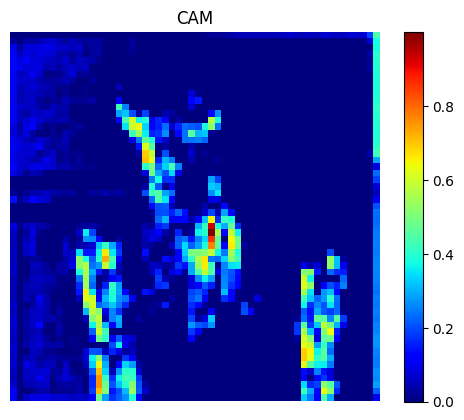

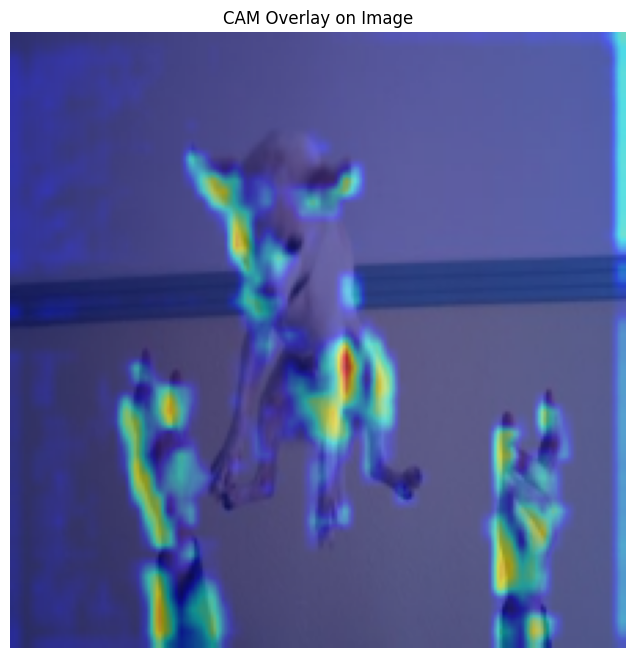

===== layer2 =====


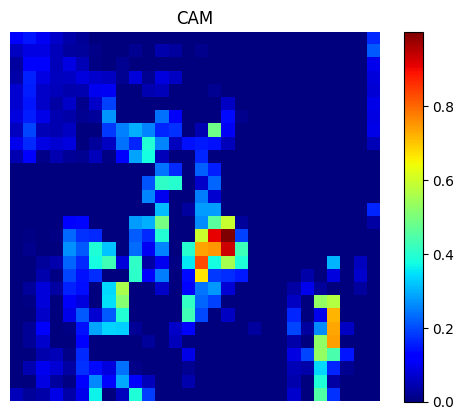

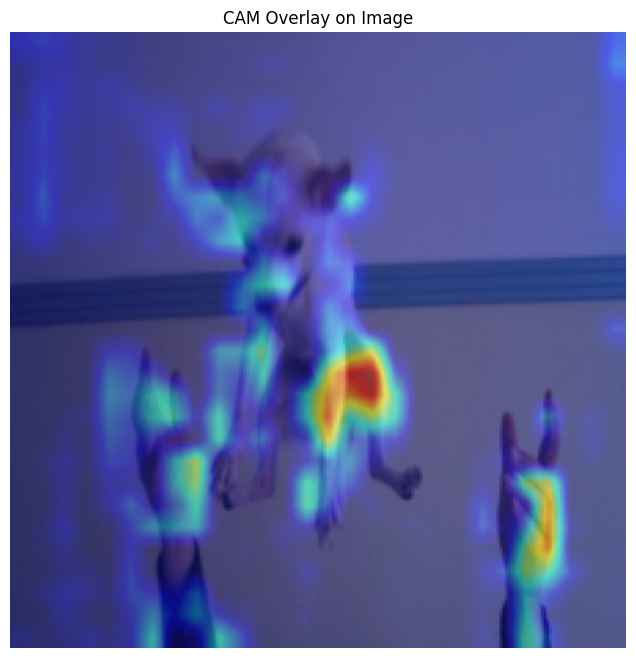

===== layer3 =====


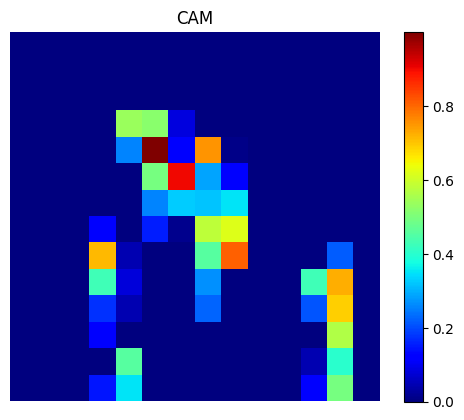

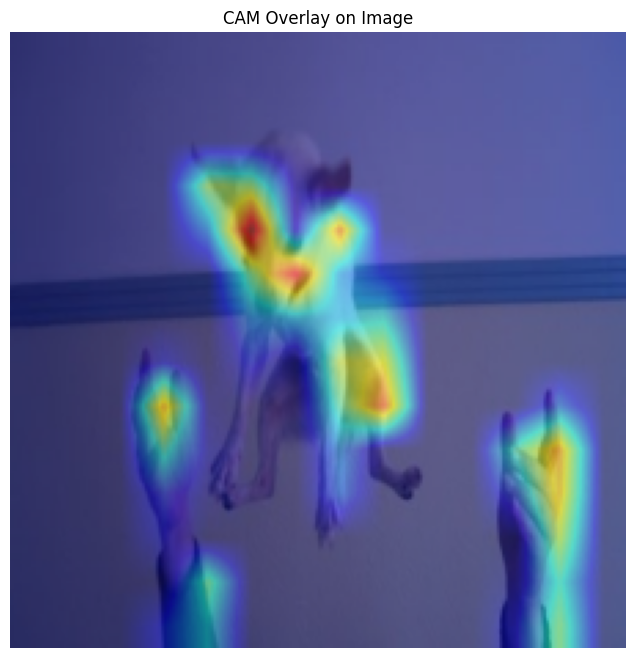

===== layer4 =====


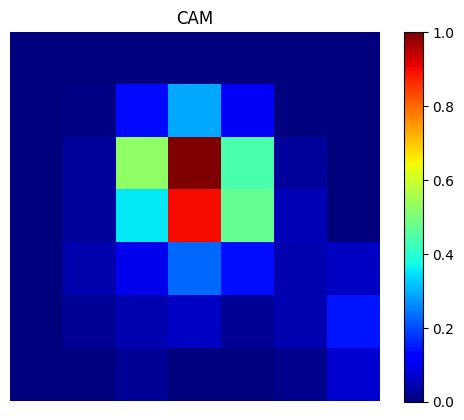

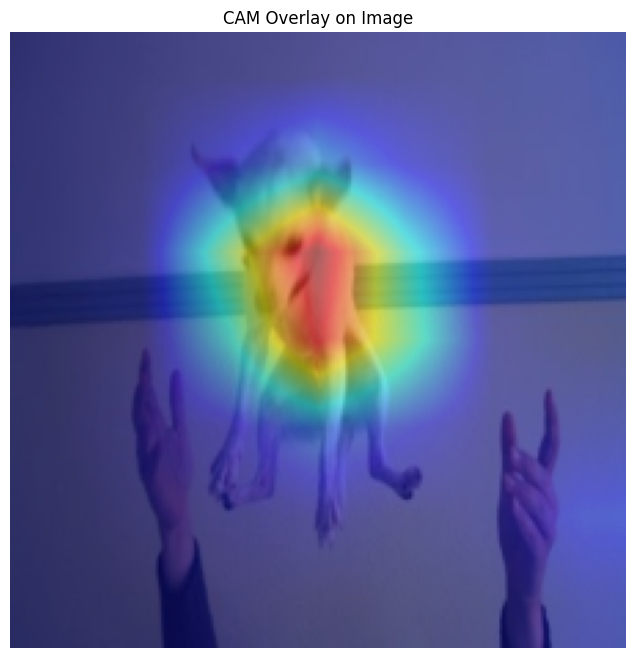

In [ ]:
# 관찰할 레이어
target_layers = ["layer1", "layer2", "layer3", "layer4"]

# 전처리된 이미지를 원본 이미지로 복원
orig_img = unnormalize(image)

# 각 레이어에 대해 Grad-CAM 생성 및 시각화
for layer_name in target_layers:

    print(f"===== {layer_name} =====")

    # Grad-CAM 생성
    grad_cam = generate_grad_cam(
        model,
        sample_image,
        target_layer_name=layer_name
    )

    # Grad-CAM 단독 시각화
    visualize_cam(grad_cam)

    # 원본 이미지 + Grad-CAM Overlay 시각화
    visualize_cam_on_image(
        grad_cam,
        orig_img
    )

# Detection with CAM

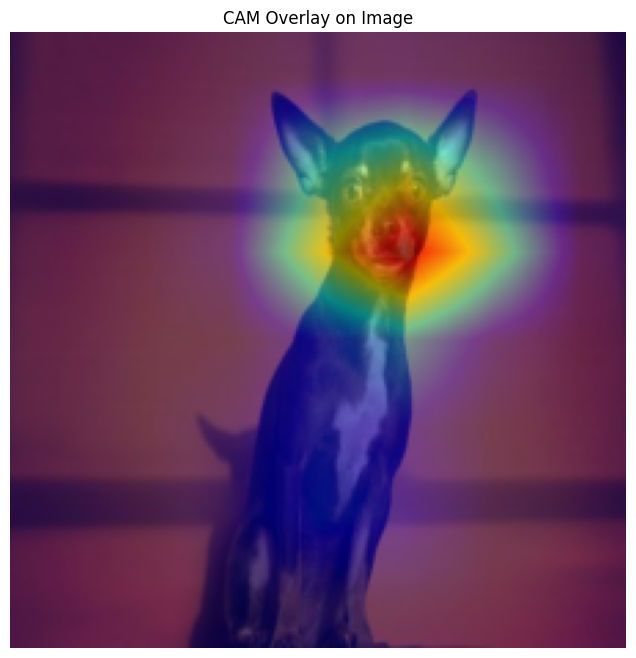

In [ ]:
image, label, ground_bbox = train_dataset[10]
sample_image = image.unsqueeze(0).to(device)
orig_img = unnormalize(image)
grad_cam = generate_grad_cam(model, sample_image, target_layer_name="layer4")

visualize_cam_on_image(grad_cam, orig_img)

In [ ]:
def get_bbox(cam, threshold=0.01):
    coords = np.argwhere(cam > threshold)
    if coords.size == 0:
        return None
    # np.argwhere의 결과는 (row, col) 즉, (y, x) 순서입니다.
    y_min, x_min = coords.min(axis=0)
    y_max, x_max = coords.max(axis=0)
    return (x_min, y_min, x_max, y_max)

In [ ]:
cam_resized = cv2.resize(grad_cam, (orig_img.shape[1], orig_img.shape[0]))
bbox = get_bbox(cam_resized, threshold=0.5)

print(bbox)

(np.int64(108), np.int64(47), np.int64(174), np.int64(101))


In [ ]:
def visualize_bbox_on_image(img, bbox, box_color=(255, 0, 0), thickness=2):
    # 원본 이미지 복사
    img_with_bbox = img.copy()
    if bbox is not None:
        x_min, y_min, x_max, y_max = bbox
        cv2.rectangle(img_with_bbox, (x_min, y_min), (x_max, y_max), box_color, thickness)
    else:
        print("활성화된 영역이 없습니다.")
    return img_with_bbox

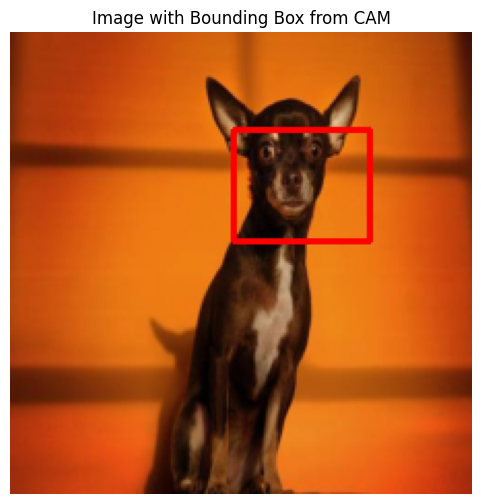

In [ ]:
img_bbox = visualize_bbox_on_image(orig_img, bbox)

plt.figure(figsize=(6,6))
plt.imshow(img_bbox)
plt.title("Image with Bounding Box from CAM")
plt.axis("off")
plt.show()

In [ ]:
# IoU(Intersection over Union)

def get_iou(bbox1, bbox2):
    # bbox 중 하나라도 None이면 IoU 0.0
    if bbox1 is None or bbox2 is None:
        return 0.0

    x_min1, y_min1, x_max1, y_max1 = bbox1
    x_min2, y_min2, x_max2, y_max2 = bbox2

    # 두 bbox의 교집합 영역 좌표 계산
    x_min_inter = max(x_min1, x_min2)
    y_min_inter = max(y_min1, y_min2)
    x_max_inter = min(x_max1, x_max2)
    y_max_inter = min(y_max1, y_max2)

    # 교집합의 너비와 높이 (음수가 되지 않도록)
    inter_width = max(0, x_max_inter - x_min_inter)
    inter_height = max(0, y_max_inter - y_min_inter)
    inter_area = inter_width * inter_height

    # 각 bbox의 면적 계산
    area1 = (x_max1 - x_min1) * (y_max1 - y_min1)
    area2 = (x_max2 - x_min2) * (y_max2 - y_min2)

    # 합집합 면적: A ∪ B = A + B - A ∩ B
    union_area = area1 + area2 - inter_area
    if union_area <= 0:
        return 0.0

    iou = inter_area / union_area
    return iou


get_iou(bbox, ground_bbox)

np.float64(0.178833195463856)

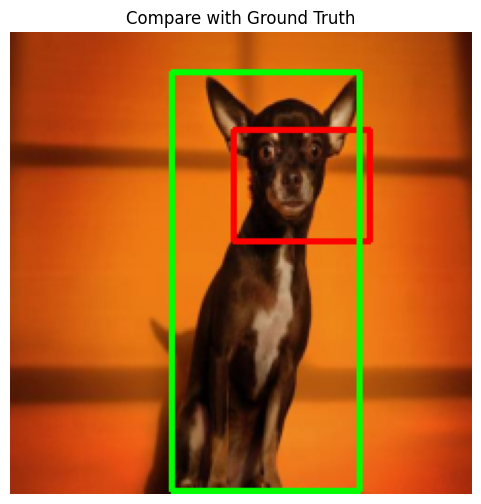

In [ ]:
def visualize_both_bbox_on_image(img, bbox, ground_truth, thickness=2):
    # 원본 이미지 복사
    img_with_bbox = img.copy()

    x_min, y_min, x_max, y_max = bbox
    cv2.rectangle(img_with_bbox, (x_min, y_min), (x_max, y_max), (255, 0, 0), thickness)

    x_min_t, y_min_t, x_max_t, y_max_t = ground_truth
    cv2.rectangle(img_with_bbox, (x_min_t, y_min_t), (x_max_t, y_max_t), (0, 255, 0), thickness)

    return img_with_bbox

ground_truth = [int(x) for x in ground_bbox]

img_bbox = visualize_both_bbox_on_image(orig_img, bbox, ground_truth)

plt.figure(figsize=(6,6))
plt.imshow(img_bbox)
plt.title("Compare with Ground Truth")
plt.axis("off")
plt.show()

- CAM을 이용해서 바운딩 박스를 그리면 객체의 일부분만 포함됨을 알 수 있다.

- 샘플 N개 뽑아서 CAM→bbox→IoU 계산

In [ ]:
def evaluate_localization(model, dataset, cam_fn, n_samples=100, threshold=0.5, seed=42):
    """
    model    : 평가할 모델
    dataset  : (image, label, bbox)를 반환하는 데이터셋
    cam_fn   : (model, image_tensor[1,C,H,W]) -> cam(np.ndarray, 0~1 정규화)
               -> Grad-CAM이든 ACoL이든 이 함수만 바꿔 끼우면 됨
    """
    rng = np.random.default_rng(seed)
    indices = rng.choice(len(dataset), size=min(n_samples, len(dataset)), replace=False)

    ious = []
    for idx in indices:
        image, label, gt_bbox = dataset[idx]
        if gt_bbox is None or (np.array(gt_bbox) == 0).all():
            continue  # annotation 없는 샘플 skip

        sample_image = image.unsqueeze(0).to(device)
        orig_img = unnormalize(image)

        cam = cam_fn(model, sample_image)
        cam_resized = cv2.resize(cam, (orig_img.shape[1], orig_img.shape[0]))
        pred_bbox = get_bbox(cam_resized, threshold=threshold)

        iou = get_iou(pred_bbox, [int(x) for x in gt_bbox])
        ious.append(iou)

    ious = np.array(ious)
    return {
        "mean": ious.mean(), "median": np.median(ious), "std": ious.std(),
        "min": ious.min(), "max": ious.max(), "count": len(ious), "values": ious,
    }

- Grad-CAM 평가

In [ ]:
from functools import partial

def gradcam_fn(model, image_tensor, target_layer_name="layer4"):
    return generate_grad_cam(model, image_tensor, target_layer_name=target_layer_name)

current_cam_fn = partial(gradcam_fn, target_layer_name="layer4")

current_stats = evaluate_localization(model, valid_dataset, current_cam_fn, n_samples=100, threshold=0.5)
print(f"[현재 모델] mean IoU: {current_stats['mean']:.4f}, median: {current_stats['median']:.4f}, n={current_stats['count']}")

[현재 모델] mean IoU: 0.2481, median: 0.2038, n=100


# ACoL
- 두 branch(A, B)를 두고 A가 강하게 반응한 영역을 지운 feature로 B를 학습시켜 두 branch가 서로 다른 영역을 보게 만드는 방식
- 일반 CAM으로 바운딩 박스를 생성하면 객체 전체가 아닌 일부분만 포함되는 것을 해결 할 수 있다.

In [ ]:
class ACoL(nn.Module):
    def __init__(self, num_classes, erase_thresh=0.6):
        super().__init__()
        backbone = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        self.features = nn.Sequential(*list(backbone.children())[:-2])  # conv~layer4
        self.erase_thresh = erase_thresh
        self.branch_a = nn.Conv2d(2048, num_classes, kernel_size=1)
        self.branch_b = nn.Conv2d(2048, num_classes, kernel_size=1)
        self.gap = nn.AdaptiveAvgPool2d(1)

    def forward(self, x):
        feat = self.features(x)
        cam_a = self.branch_a(feat)
        logits_a = self.gap(cam_a).flatten(1)

        with torch.no_grad():
            pred_a = logits_a.argmax(dim=1)
            cam_a_pred = cam_a[torch.arange(cam_a.size(0)), pred_a]
            cam_a_norm = (cam_a_pred - cam_a_pred.amin(dim=(1,2), keepdim=True)) / \
                         (cam_a_pred.amax(dim=(1,2), keepdim=True) - cam_a_pred.amin(dim=(1,2), keepdim=True) + 1e-8)
            erase_mask = (cam_a_norm < self.erase_thresh).float().unsqueeze(1)

        cam_b = self.branch_b(feat * erase_mask)
        logits_b = self.gap(cam_b).flatten(1)
        return logits_a, logits_b, cam_a, cam_b

In [ ]:
def train_acol(model, train_loader, optimizer, num_epochs=2):
    criterion = nn.CrossEntropyLoss()
    for epoch in range(num_epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for batch_idx, (images, labels, _) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            logits_a, logits_b, _, _ = model(images)
            loss = criterion(logits_a, labels) + criterion(logits_b, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            preds = logits_b.argmax(dim=1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()
            if (batch_idx + 1) % 50 == 0:
                print(f"  Step {batch_idx+1} - Loss: {loss.item():.4f}")

        print(f"Epoch {epoch+1} - Loss: {running_loss/(batch_idx+1):.4f}, Acc: {correct/total*100:.2f}%")
    return model


acol_model = ACoL(num_classes=num_classes).to(device)
acol_optimizer = optim.SGD(acol_model.parameters(), lr=0.01, momentum=0.9)
acol_model = train_acol(acol_model, train_loader, acol_optimizer, num_epochs=2)

  Step 50 - Loss: 11.7194
  Step 100 - Loss: 9.9466
  Step 150 - Loss: 10.1669
  Step 200 - Loss: 9.7856
  Step 250 - Loss: 9.8201
  Step 300 - Loss: 8.8664
  Step 350 - Loss: 9.4709
  Step 400 - Loss: 8.6937
  Step 450 - Loss: 8.6319
  Step 500 - Loss: 8.5640
  Step 550 - Loss: 8.0092
  Step 600 - Loss: 8.2803
  Step 650 - Loss: 7.8913
  Step 700 - Loss: 7.8678
  Step 750 - Loss: 8.3475
  Step 800 - Loss: 7.7375
  Step 850 - Loss: 6.7975
  Step 900 - Loss: 7.2568
  Step 950 - Loss: 7.1920
  Step 1000 - Loss: 8.4982
Epoch 1 - Loss: 8.7228, Acc: 4.76%
  Step 50 - Loss: 7.0354
  Step 100 - Loss: 7.3446
  Step 150 - Loss: 6.6360
  Step 200 - Loss: 7.6301
  Step 250 - Loss: 7.1645
  Step 300 - Loss: 6.4448
  Step 350 - Loss: 6.5177
  Step 400 - Loss: 7.4365
  Step 450 - Loss: 7.2752
  Step 500 - Loss: 6.8251
  Step 550 - Loss: 7.8668
  Step 600 - Loss: 6.8095
  Step 650 - Loss: 7.2342
  Step 700 - Loss: 7.7694
  Step 750 - Loss: 6.7135
  Step 800 - Loss: 6.7032
  Step 850 - Loss: 6.6995
  

- ACoL 모델 평가

In [ ]:
def acol_cam_fn(model, image_tensor):
    model.eval()
    with torch.no_grad():
        logits_a, logits_b, cam_a, cam_b = model(image_tensor)
        pred_class = logits_b.argmax(dim=1).item()
        cam = (cam_a[0, pred_class] + cam_b[0, pred_class]).cpu().numpy()
    cam = np.maximum(cam, 0)
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
    return cam

acol_stats = evaluate_localization(acol_model, valid_dataset, acol_cam_fn, n_samples=100, threshold=0.5)
print(f"[ACoL 모델] mean IoU: {acol_stats['mean']:.4f}, median: {acol_stats['median']:.4f}, n={acol_stats['count']}")

[ACoL 모델] mean IoU: 0.5506, median: 0.5667, n=100


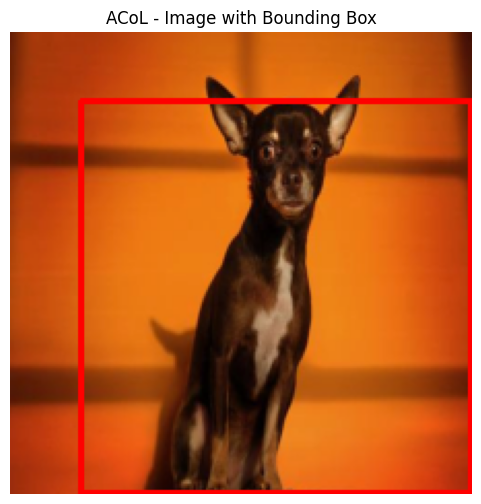

In [ ]:
image, label, ground_bbox = train_dataset[10]
sample_image = image.unsqueeze(0).to(device)
orig_img = unnormalize(image)

acol_cam = acol_cam_fn(acol_model, sample_image)
cam_resized = cv2.resize(acol_cam, (orig_img.shape[1], orig_img.shape[0]))
acol_bbox = get_bbox(cam_resized, threshold=0.5)

img_bbox = visualize_bbox_on_image(orig_img, acol_bbox)

plt.figure(figsize=(6,6))
plt.imshow(img_bbox)
plt.title("ACoL - Image with Bounding Box")
plt.axis("off")
plt.show()

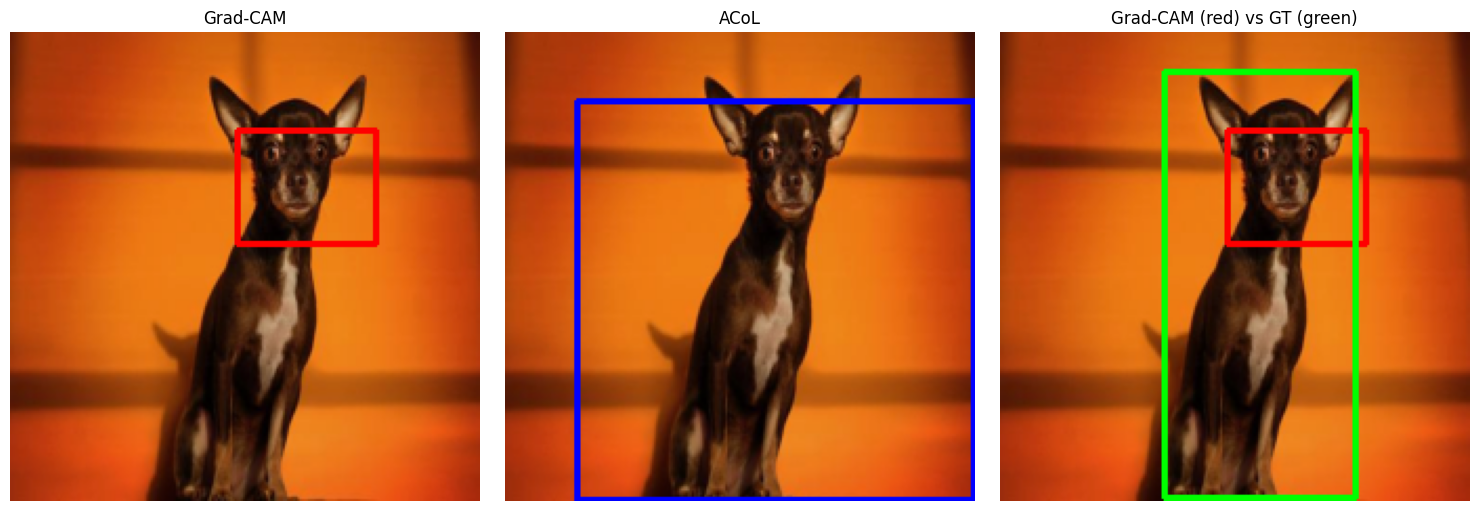

In [ ]:
grad_cam = generate_grad_cam(model, sample_image, target_layer_name="layer4")
cam_resized_g = cv2.resize(grad_cam, (orig_img.shape[1], orig_img.shape[0]))
grad_bbox = get_bbox(cam_resized_g, threshold=0.5)

ground_truth = [int(x) for x in ground_bbox]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(visualize_bbox_on_image(orig_img, grad_bbox, box_color=(255,0,0)))
axes[0].set_title("Grad-CAM"); axes[0].axis("off")

axes[1].imshow(visualize_bbox_on_image(orig_img, acol_bbox, box_color=(0,0,255)))
axes[1].set_title("ACoL"); axes[1].axis("off")

axes[2].imshow(visualize_both_bbox_on_image(orig_img, grad_bbox, ground_truth))
axes[2].set_title("Grad-CAM (red) vs GT (green)"); axes[2].axis("off")

plt.tight_layout()
plt.show()

- 비교 시각화

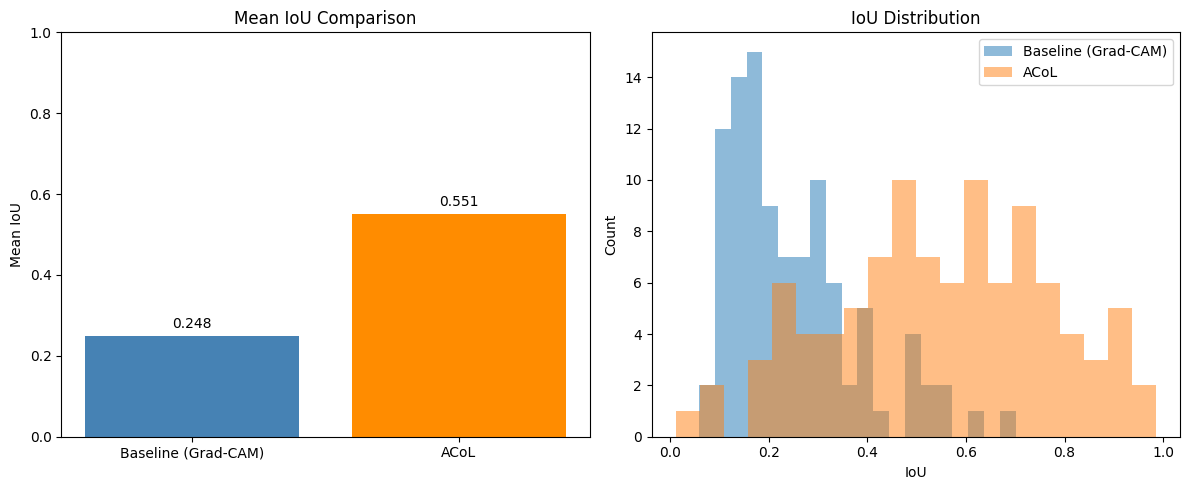

In [ ]:
def compare_iou_stats(stats_dict):
    names = list(stats_dict.keys())
    means = [stats_dict[n]["mean"] for n in names]

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].bar(names, means, color=["steelblue", "darkorange"][:len(names)])
    axes[0].set_ylabel("Mean IoU")
    axes[0].set_title("Mean IoU Comparison")
    axes[0].set_ylim(0, 1)
    for i, v in enumerate(means):
        axes[0].text(i, v + 0.02, f"{v:.3f}", ha="center")

    for n in names:
        axes[1].hist(stats_dict[n]["values"], bins=20, alpha=0.5, label=n)
    axes[1].set_xlabel("IoU"); axes[1].set_ylabel("Count")
    axes[1].set_title("IoU Distribution"); axes[1].legend()

    plt.tight_layout()
    plt.show()


compare_iou_stats({
    "Baseline (Grad-CAM)": current_stats,
    "ACoL": acol_stats,
})

- 에포크 수를 2->5로 증가 시켜보기

In [ ]:
acol_model = ACoL(num_classes=num_classes).to(device)
acol_optimizer = optim.SGD(acol_model.parameters(), lr=0.01, momentum=0.9)
acol_model = train_acol(acol_model, train_loader, acol_optimizer, num_epochs=5)

  Step 50 - Loss: 8.1582
  Step 100 - Loss: 9.5455
  Step 150 - Loss: 8.1638
  Step 200 - Loss: 8.6228
  Step 250 - Loss: 7.8006
  Step 300 - Loss: 8.6453
  Step 350 - Loss: 9.1711
  Step 400 - Loss: 7.6203
  Step 450 - Loss: 8.9293
  Step 500 - Loss: 7.2878
  Step 550 - Loss: 6.6375
  Step 600 - Loss: 7.1084
  Step 650 - Loss: 7.3857
  Step 700 - Loss: 7.8405
  Step 750 - Loss: 6.8241
  Step 800 - Loss: 8.1848
  Step 850 - Loss: 6.1787
  Step 900 - Loss: 7.1087
  Step 950 - Loss: 7.0859
  Step 1000 - Loss: 7.4652
Epoch 1 - Loss: 7.7085, Acc: 10.84%
  Step 50 - Loss: 7.0690
  Step 100 - Loss: 5.6712
  Step 150 - Loss: 8.4299
  Step 200 - Loss: 6.2991
  Step 250 - Loss: 6.9184
  Step 300 - Loss: 6.4302
  Step 350 - Loss: 5.7555
  Step 400 - Loss: 7.9909
  Step 450 - Loss: 7.3220
  Step 500 - Loss: 5.7332
  Step 550 - Loss: 8.0132
  Step 600 - Loss: 5.0957
  Step 650 - Loss: 5.3667
  Step 700 - Loss: 5.1959
  Step 750 - Loss: 6.1077
  Step 800 - Loss: 4.1739
  Step 850 - Loss: 6.0550
  S

- ACoL(epoch=5) 모델 평가

In [ ]:
def acol_cam_fn(model, image_tensor):
    model.eval()
    with torch.no_grad():
        logits_a, logits_b, cam_a, cam_b = model(image_tensor)
        pred_class = logits_b.argmax(dim=1).item()
        cam = (cam_a[0, pred_class] + cam_b[0, pred_class]).cpu().numpy()
    cam = np.maximum(cam, 0)
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
    return cam

acol_stats = evaluate_localization(acol_model, valid_dataset, acol_cam_fn, n_samples=100, threshold=0.5)
print(f"[ACoL 모델] mean IoU: {acol_stats['mean']:.4f}, median: {acol_stats['median']:.4f}, n={acol_stats['count']}")

[ACoL 모델] mean IoU: 0.5068, median: 0.4552, n=100


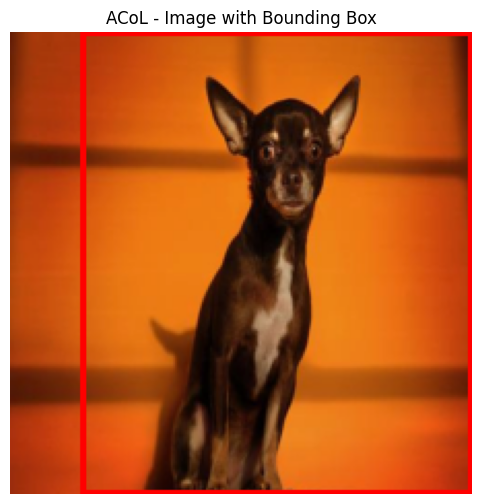

In [ ]:
image, label, ground_bbox = train_dataset[10]
sample_image = image.unsqueeze(0).to(device)
orig_img = unnormalize(image)

acol_cam = acol_cam_fn(acol_model, sample_image)
cam_resized = cv2.resize(acol_cam, (orig_img.shape[1], orig_img.shape[0]))
acol_bbox = get_bbox(cam_resized, threshold=0.5)

img_bbox = visualize_bbox_on_image(orig_img, acol_bbox)

plt.figure(figsize=(6,6))
plt.imshow(img_bbox)
plt.title("ACoL - Image with Bounding Box")
plt.axis("off")
plt.show()

- 비교 시각화

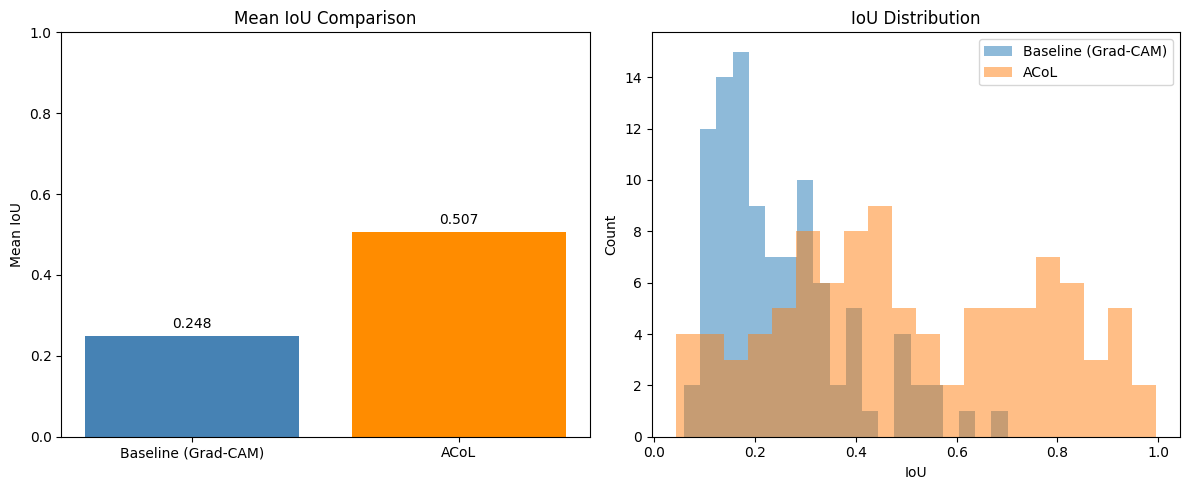

In [ ]:
def compare_iou_stats(stats_dict):
    names = list(stats_dict.keys())
    means = [stats_dict[n]["mean"] for n in names]

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].bar(names, means, color=["steelblue", "darkorange"][:len(names)])
    axes[0].set_ylabel("Mean IoU")
    axes[0].set_title("Mean IoU Comparison")
    axes[0].set_ylim(0, 1)
    for i, v in enumerate(means):
        axes[0].text(i, v + 0.02, f"{v:.3f}", ha="center")

    for n in names:
        axes[1].hist(stats_dict[n]["values"], bins=20, alpha=0.5, label=n)
    axes[1].set_xlabel("IoU"); axes[1].set_ylabel("Count")
    axes[1].set_title("IoU Distribution"); axes[1].legend()

    plt.tight_layout()
    plt.show()


compare_iou_stats({
    "Baseline (Grad-CAM)": current_stats,
    "ACoL": acol_stats,
})

- 바운딩 박스가 정답보다 큰 문제를 해결 해보기 위해 erase_thresh=0.6에서 0.4로 줄인 뒤 재학습

In [ ]:
# acol_model(erase_thresh=0.6) 평가 결과 저장
acol_stats_v1 = evaluate_localization(acol_model, valid_dataset, acol_cam_fn, n_samples=100, threshold=0.5)
print(f"[ACoL v1, erase_thresh=0.6] mean IoU: {acol_stats_v1['mean']:.4f}")

[ACoL v1, erase_thresh=0.6] mean IoU: 0.5068


In [ ]:
acol_model2 = ACoL(num_classes=num_classes, erase_thresh=0.4).to(device)  # 0.6 -> 0.4

acol_optimizer = optim.SGD(acol_model2.parameters(), lr=0.01, momentum=0.9)
acol_model2 = train_acol(acol_model2, train_loader, acol_optimizer, num_epochs=5)

  Step 50 - Loss: 9.1344
  Step 100 - Loss: 7.7076
  Step 150 - Loss: 8.4649
  Step 200 - Loss: 7.8077
  Step 250 - Loss: 8.2957
  Step 300 - Loss: 7.5493
  Step 350 - Loss: 7.8560
  Step 400 - Loss: 6.6916
  Step 450 - Loss: 8.2962
  Step 500 - Loss: 7.0829
  Step 550 - Loss: 7.8770
  Step 600 - Loss: 6.9534
  Step 650 - Loss: 8.2664
  Step 700 - Loss: 7.1379
  Step 750 - Loss: 9.1633
  Step 800 - Loss: 6.6093
  Step 850 - Loss: 7.3157
  Step 900 - Loss: 8.2628
  Step 950 - Loss: 7.1912
  Step 1000 - Loss: 5.7941
Epoch 1 - Loss: 7.9023, Acc: 7.55%
  Step 50 - Loss: 6.4266
  Step 100 - Loss: 7.2205
  Step 150 - Loss: 7.5670
  Step 200 - Loss: 7.3791
  Step 250 - Loss: 6.0732
  Step 300 - Loss: 5.7707
  Step 350 - Loss: 6.0240
  Step 400 - Loss: 6.2660
  Step 450 - Loss: 7.1503
  Step 500 - Loss: 5.5595
  Step 550 - Loss: 6.2759
  Step 600 - Loss: 7.2324
  Step 650 - Loss: 7.8289
  Step 700 - Loss: 5.8136
  Step 750 - Loss: 6.6227
  Step 800 - Loss: 5.8344
  Step 850 - Loss: 6.4341
  St

- ACoL(erase_thresh=0.6, epoch=5) 모델 평가

In [ ]:
def acol_cam_fn(model, image_tensor):
    model.eval()
    with torch.no_grad():
        logits_a, logits_b, cam_a, cam_b = model(image_tensor)
        pred_class = logits_b.argmax(dim=1).item()
        cam = (cam_a[0, pred_class] + cam_b[0, pred_class]).cpu().numpy()
    cam = np.maximum(cam, 0)
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
    return cam

acol_stats = evaluate_localization(acol_model2, valid_dataset, acol_cam_fn, n_samples=100, threshold=0.5)
print(f"[ACoL 모델] mean IoU: {acol_stats['mean']:.4f}, median: {acol_stats['median']:.4f}, n={acol_stats['count']}")

[ACoL 모델] mean IoU: 0.4194, median: 0.4237, n=100


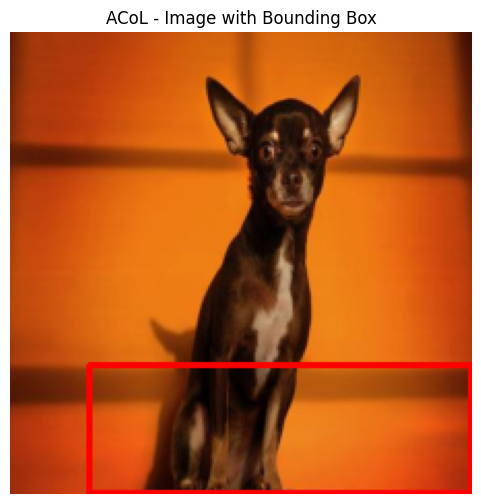

In [ ]:
image, label, ground_bbox = train_dataset[10]
sample_image = image.unsqueeze(0).to(device)
orig_img = unnormalize(image)

acol_cam = acol_cam_fn(acol_model2, sample_image)
cam_resized = cv2.resize(acol_cam, (orig_img.shape[1], orig_img.shape[0]))
acol_bbox = get_bbox(cam_resized, threshold=0.5)

img_bbox = visualize_bbox_on_image(orig_img, acol_bbox)

plt.figure(figsize=(6,6))
plt.imshow(img_bbox)
plt.title("ACoL - Image with Bounding Box")
plt.axis("off")
plt.show()

In [ ]:
# acol_model2 (erase_thresh=0.4) 평가 결과
acol_stats_v2 = evaluate_localization(acol_model2, valid_dataset, acol_cam_fn, n_samples=100, threshold=0.5)
print(f"[ACoL v2, erase_thresh=0.4] mean IoU: {acol_stats_v2['mean']:.4f}")

[ACoL v2, erase_thresh=0.4] mean IoU: 0.4194


- 비교 시각화

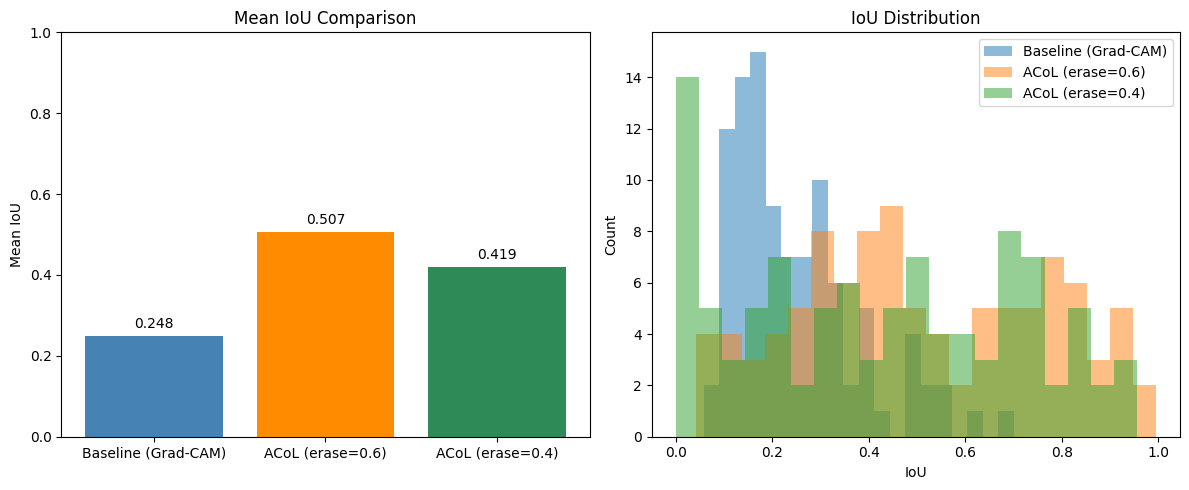

In [ ]:
def compare_iou_stats(stats_dict):
    names = list(stats_dict.keys())
    means = [stats_dict[n]["mean"] for n in names]
    colors = ["steelblue", "darkorange", "seagreen", "purple"][:len(names)]

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].bar(names, means, color=colors)
    axes[0].set_ylabel("Mean IoU")
    axes[0].set_title("Mean IoU Comparison")
    axes[0].set_ylim(0, 1)
    for i, v in enumerate(means):
        axes[0].text(i, v + 0.02, f"{v:.3f}", ha="center")

    for n in names:
        axes[1].hist(stats_dict[n]["values"], bins=20, alpha=0.5, label=n)
    axes[1].set_xlabel("IoU"); axes[1].set_ylabel("Count")
    axes[1].set_title("IoU Distribution"); axes[1].legend()

    plt.tight_layout()
    plt.show()


compare_iou_stats({
    "Baseline (Grad-CAM)": current_stats,
    "ACoL (erase=0.6, epoch=5)": acol_stats_v1,
    "ACoL (erase=0.4, epoch=5)": acol_stats_v2,
})

# 결과 비교 분석

ResNet 기반 모델에서 Grad-CAM 1개 조건과 ACoL 3개 조건을 비교한 결과는 다음과 같다.

| 모델       | Epoch | Erase Threshold |   Mean IoU | Median IoU |
| -------- | ----: | --------------: | ---------: | ---------: |
| Grad-CAM |     2 |               - | 0.2481 | 0.2038 |
| ACoL     |     2 |             0.6 | 0.5506 | 0.5667 |
| ACoL     |     5 |             0.6 | 0.5068 | 0.4552 |
| ACoL     |     5 |             0.4 | 0.4194 | 0.4237 |

모든 실험은 n=100으로 동일하게 평가되었으므로 각 조건의 IoU를 직접 비교할 수 있다.

## 1. Grad-CAM과 ACoL 비교

가장 큰 차이는 Grad-CAM보다 ACoL의 객체 위치 추정 성능이 크게 향상되었다는 점이다.

Grad-CAM의 평균 IoU는 **0.2481**, 중앙값은 **0.2038**이었다. 반면 가장 좋은 ACoL 설정인 `epoch=2, erase_thresh=0.6`에서는 평균 IoU가 **0.5506**, 중앙값이 **0.5667**로 나타났다.

이는 단순히 일부 이미지에서 높은 IoU를 얻은 것이 아니라 전체적인 객체 위치 추정 성능 자체가 개선되었을 가능성을 보여준다.

특히 평균보다 중앙값이 더 높다는 점도 주목할 필요가 있다. ACoL의 경우 중앙값이 0.5667이므로, 적어도 평가 데이터의 절반 정도에서는 IoU가 이 수준 이상이었다고 볼 수 있다.

## 2. ACoL의 Epoch에 따른 변화

`erase_thresh=0.6`을 고정하고 epoch만 변경하면 다음과 같다.

* Epoch 2: **mean IoU = 0.5506, median = 0.5667**
* Epoch 5: **mean IoU = 0.5068, median = 0.4552**

Epoch를 2에서 5로 증가시켰을 때 오히려 성능이 감소했다.

평균 IoU는 0.5506 → 0.5068로 약 0.0438p 감소했고, 중앙값은 0.5667 → 0.4552로 약 0.1115p 감소했다.

이는 ACoL에서 더 오래 학습한다고 해서 반드시 localization 성능이 향상되는 것은 아니라는 것을 보여준다.

ACoL은 초기의 가장 강한 활성 영역을 erase하여 모델이 다른 영역을 학습하도록 유도하지만 학습이 계속되면서 모델이 다시 특정한 강한 특징에 의존할 가능성이 있다.

따라서 이번 결과에서는 epoch=2가 epoch=5보다 localization 관점에서 더 적절한 학습 지점이었을 가능성이 있다.

## 3. Erase Threshold에 따른 변화

Epoch를 5로 고정하고 `erase_thresh`를 변경한 결과는 다음과 같다.

* `erase_thresh=0.6`: **mean IoU = 0.5068**
* `erase_thresh=0.4`: **mean IoU = 0.4194**

즉, threshold를 0.6 → 0.4로 낮추었을 때 평균 IoU가 0.0874p 감소했다.

중앙값 역시 0.4552 → 0.4237로 감소했다.

따라서 현재 실험에서는 `erase_thresh=0.4`보다 **`erase_thresh=0.6`이 더 좋은 localization 성능**을 보였다.

ACoL의 erase 과정에서는 activation map에서 특정 threshold 이상의 영역을 제거하기 때문에 threshold가 ACoL이 제거하는 영역의 범위에 영향을 준다. 따라서 threshold가 너무 낮아지면 **상대적으로 넓은 영역이 erase되어 객체의 중요한 특징까지 과도하게 제거될 가능성**이 있다.

## 4. 결론
현재 결과는 각 조건에서 **100개의 샘플만 평가한 결과**이므로, 최종적인 결론을 위해서는 더 많은 데이터에 대한 평가와 함께 classification accuracy, IoU 분포, 그리고 실제 activation map의 시각적 비교를 함께 수행하는 것이 바람직하다.